# Task 3 — Pix2Pix Facades Demo

This notebook prepares the inference demo for the selected Pix2Pix generator.

The selected model is the best M4 checkpoint obtained during the experiments done in the previous notebook:

```text
m4_generator_perc_5.pth
```

The checkpoint is loaded into the resize-convolution U-Net generator and exported as a TorchScript model. The final demo folder contains:

```text
demo/
├── inference.py
├── requirements.txt
├── README.md
├── models/
│   └── pix2pix_generator.pt
├── samples/
│   └── sample_label_map.jpg
└── outputs/
    └── generated_sample.png
```

## 1. Imports and folder structure

The following cell imports the required libraries and creates the folder structure used by the demo.

In [1]:
from pathlib import Path
import shutil
import subprocess
import sys

import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt

ROOT = Path.cwd()
DEMO_DIR = ROOT / "demo"

MODELS_DIR = DEMO_DIR / "models"
SAMPLES_DIR = DEMO_DIR / "samples"
OUTPUTS_DIR = DEMO_DIR / "outputs"

MODEL_PATH = MODELS_DIR / "pix2pix_generator.pt"
SAMPLE_PATH = SAMPLES_DIR / "sample_label_map.jpg"
OUTPUT_PATH = OUTPUTS_DIR / "generated_sample.png"

for folder in [DEMO_DIR, MODELS_DIR, SAMPLES_DIR, OUTPUTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Root folder:", ROOT.resolve())
print("Demo folder:", DEMO_DIR.resolve())
print("Device:", device)

Root folder: /Users/ana/Documents/DEMO
Demo folder: /Users/ana/Documents/DEMO/demo
Device: cpu


## 2. Select the final `.pth` checkpoint

The final selected checkpoint is set manually because the demo notebook does not depend on any auxiliary results file.

If the checkpoint has another name, change `SELECTED_CHECKPOINT` in the next cell.

In [2]:
# Selected final checkpoint.
# Change this line only if your file has a different name.
SELECTED_CHECKPOINT = Path("m4_generator_perc_5.pth")

if not SELECTED_CHECKPOINT.exists():
    available_checkpoints = sorted(ROOT.glob("m4_generator_perc_*.pth"))

    print("Selected checkpoint not found:", SELECTED_CHECKPOINT)

    if len(available_checkpoints) > 0:
        print("\nAvailable M4 checkpoints:")
        for checkpoint in available_checkpoints:
            print(" -", checkpoint.name)

    raise FileNotFoundError(
        "Place the selected M4 .pth checkpoint in the same folder as this notebook, "
        "or update SELECTED_CHECKPOINT with the correct filename."
    )

print("Selected checkpoint:", SELECTED_CHECKPOINT.resolve())

Selected checkpoint: /Users/ana/Documents/DEMO/m4_generator_perc_5.pth


## 3. Define the generator architecture

The selected checkpoint was trained with the resize-convolution U-Net generator.  
The same architecture must be recreated before loading the `.pth` weights.

In [3]:
class UNetDown(nn.Module):
    def __init__(self, in_channels, out_channels, normalize=True):
        super().__init__()

        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            )
        ]

        if normalize:
            layers.append(nn.BatchNorm2d(out_channels))

        layers.append(nn.LeakyReLU(0.2, inplace=True))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class UNetUpResize(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()

        layers = [
            nn.Upsample(
                scale_factor=2,
                mode="bilinear",
                align_corners=False
            ),
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]

        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        self.model = nn.Sequential(*layers)

    def forward(self, x, skip):
        x = self.model(x)
        x = torch.cat((x, skip), dim=1)
        return x


class GeneratorUNetResize(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()

        self.down1 = UNetDown(in_channels, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512)
        self.down5 = UNetDown(512, 512)
        self.down6 = UNetDown(512, 512)
        self.down7 = UNetDown(512, 512)
        self.down8 = UNetDown(512, 512, normalize=False)

        self.up1 = UNetUpResize(512, 512, dropout=0.5)
        self.up2 = UNetUpResize(1024, 512, dropout=0.5)
        self.up3 = UNetUpResize(1024, 512, dropout=0.5)
        self.up4 = UNetUpResize(1024, 512)
        self.up5 = UNetUpResize(1024, 256)
        self.up6 = UNetUpResize(512, 128)
        self.up7 = UNetUpResize(256, 64)

        self.final = nn.Sequential(
            nn.Upsample(
                scale_factor=2,
                mode="bilinear",
                align_corners=False
            ),
            nn.Conv2d(
                128,
                out_channels,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        d8 = self.down8(d7)

        u1 = self.up1(d8, d7)
        u2 = self.up2(u1, d6)
        u3 = self.up3(u2, d5)
        u4 = self.up4(u3, d4)
        u5 = self.up5(u4, d3)
        u6 = self.up6(u5, d2)
        u7 = self.up7(u6, d1)

        return self.final(u7)

## 4. Load the `.pth` checkpoint

The `.pth` file contains the trained weights.  
The weights are loaded into the generator architecture and the model is put in evaluation mode.

In [4]:
generator = GeneratorUNetResize().to(device)

state_dict = torch.load(SELECTED_CHECKPOINT, map_location=device)
generator.load_state_dict(state_dict)
generator.eval()

print("Checkpoint loaded correctly.")

Checkpoint loaded correctly.


## 5. Export the generator as TorchScript

The generator is exported as a TorchScript `.pt` file.  
This makes the standalone inference script simpler because it can load the model directly with `torch.jit.load`.

In [5]:
generator_cpu = generator.cpu()
generator_cpu.eval()

example_input = torch.randn(1, 3, 256, 256)

with torch.no_grad():
    traced_generator = torch.jit.trace(generator_cpu, example_input)

traced_generator.save(str(MODEL_PATH))

print("Exported model saved to:", MODEL_PATH)
print("File exists:", MODEL_PATH.exists())

Exported model saved to: /Users/ana/Documents/DEMO/demo/models/pix2pix_generator.pt
File exists: True


## 6. Create the inference script

The script receives an input label map, loads the exported generator and saves the generated facade image.

In [6]:
inference_code = r"""
import argparse
from pathlib import Path

import torch
from PIL import Image
from torchvision import transforms


def load_input_image(image_path, paired=False):
    image = Image.open(image_path).convert("RGB")

    if paired:
        width, height = image.size
        mid = width // 2
        image = image.crop((mid, 0, width, height))

    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5)
        )
    ])

    return transform(image).unsqueeze(0)


def tensor_to_image(tensor):
    tensor = tensor.squeeze(0).detach().cpu()
    tensor = (tensor * 0.5 + 0.5).clamp(0, 1)
    return transforms.ToPILImage()(tensor)


def main():
    parser = argparse.ArgumentParser(
        description="Pix2Pix Facades inference demo."
    )

    parser.add_argument(
        "--input",
        type=str,
        required=True,
        help="Path to the input label map image."
    )

    parser.add_argument(
        "--model",
        type=str,
        default="models/pix2pix_generator.pt",
        help="Path to the exported TorchScript generator model."
    )

    parser.add_argument(
        "--output",
        type=str,
        default="outputs/generated_image.png",
        help="Path where the generated image will be saved."
    )

    parser.add_argument(
        "--paired",
        action="store_true",
        help=(
            "Use this flag if the input is a paired Facades image. "
            "The right half will be used as the label map."
        )
    )

    args = parser.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    model = torch.jit.load(args.model, map_location=device)
    model.to(device)
    model.eval()

    input_tensor = load_input_image(args.input, paired=args.paired).to(device)

    with torch.no_grad():
        generated_tensor = model(input_tensor)

    output_image = tensor_to_image(generated_tensor)

    output_path = Path(args.output)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_image.save(output_path)

    print("Generated image saved to:", output_path)


if __name__ == "__main__":
    main()
"""

inference_path = DEMO_DIR / "inference.py"
inference_path.write_text(inference_code, encoding="utf-8")

print("Created:", inference_path)

Created: /Users/ana/Documents/DEMO/demo/inference.py


## 7. Create `requirements.txt`

This file contains the dependencies required to run the demo.

In [7]:
requirements = [
    "torch",
    "torchvision",
    "pillow",
    "matplotlib",
]

requirements_path = DEMO_DIR / "requirements.txt"
requirements_path.write_text("\n".join(requirements) + "\n", encoding="utf-8")

print("Created:", requirements_path)

Created: /Users/ana/Documents/DEMO/demo/requirements.txt


## 8. Create `README.md`

The README explains how to install the dependencies and run inference from a terminal.

In [8]:
readme_lines = [
    "# Pix2Pix Facades Demo",
    "",
    "This repository contains an inference demo for an image-to-image translation model trained on the Facades dataset.",
    "",
    "The model receives a semantic label map of a building facade and generates a realistic facade image using a trained Pix2Pix generator.",
    "",
    "## Project description",
    "",
    "The objective of this project is to use image-to-image translation models, such as Pix2Pix, to generate realistic images from input label maps.",
    "",
    "In this demo, the input is a facade label map and the output is a generated realistic facade image.",
    "",
    "## Installation",
    "",
    "Run the following commands from the folder that contains `inference.py`.",
    "",
    "Install the required dependencies:",
    "",
    "```bash",
    "pip install -r requirements.txt",
    "```",
    "",
    "## Running inference",
    "",
    "To generate a facade image from the sample label map, run:",
    "",
    "```bash",
    "python inference.py --input samples/sample_label_map.jpg --model models/pix2pix_generator.pt --output outputs/generated_sample.png",
    "```",
    "",
    "The generated image will be saved in:",
    "",
    "```text",
    "outputs/generated_sample.png",
    "```",
    "",
    "## Input format",
    "",
    "The input image must be an RGB semantic label map.",
    "",
    "The image is automatically resized to 256 x 256 before being passed to the generator.",
    "",
    "If the input image is a paired Facades image, where the real facade is on the left and the label map is on the right, run:",
    "",
    "```bash",
    "python inference.py --input samples/paired_image.jpg --model models/pix2pix_generator.pt --output outputs/generated_sample.png --paired",
    "```",
    "",
    "In that case, the script automatically crops the right half of the image and uses it as the label map.",
    "",
    "## Model",
    "",
    "The model used in this demo is an exported trained Pix2Pix generator.",
    "",
    "The generator receives a label map and produces a realistic facade image.",
    "",
    "The model was exported as a TorchScript file so that the inference script can load it directly without redefining the full architecture.",
    "",
    "## Files",
    "",
    "### `inference.py`",
    "",
    "Python script used to run inference with the trained generator.",
    "",
    "### `requirements.txt`",
    "",
    "List of Python dependencies required to run the demo.",
    "",
    "### `models/pix2pix_generator.pt`",
    "",
    "Exported trained generator model.",
    "",
    "### `samples/sample_label_map.jpg`",
    "",
    "Example input label map.",
    "",
    "### `outputs/`",
    "",
    "Folder where generated images are saved.",
    "",
    "## Notes",
    "",
    "This repository only contains the inference demo.",
    "",
]

readme_path = DEMO_DIR / "README.md"
readme_path.write_text("\n".join(readme_lines), encoding="utf-8")

print("Created:", readme_path)

Created: /Users/ana/Documents/DEMO/demo/README.md


## 9. Prepare a sample input label map

The demo needs at least one sample label map. If `demo/samples/sample_label_map.jpg` already exists, it is reused.

If it does not exist, the notebook searches for a Facades paired image and crops the right half as the label map.

In [9]:
if SAMPLE_PATH.exists():
    print("Sample already exists:", SAMPLE_PATH)
else:
    candidate_dirs = [
        ROOT / "facades",
        ROOT / "facades" / "facades",
        ROOT / "data" / "facades",
        ROOT / "data" / "facades" / "facades",
        ROOT / "datasets" / "facades",
        ROOT / "datasets" / "facades" / "facades",
        Path("/kaggle/input/datasets/modiegoti/facades/facades"),
    ]

    image_files = []

    for folder in candidate_dirs:
        if folder.exists():
            image_files = sorted(folder.glob("*.jpg"))
            if not image_files:
                image_files = sorted(folder.rglob("*.jpg"))
            if image_files:
                print("Dataset folder found:", folder)
                break

    if not image_files:
        raise FileNotFoundError(
            "No Facades image was found automatically. "
            "Place a label map manually at demo/samples/sample_label_map.jpg."
        )

    paired_img = Image.open(image_files[0]).convert("RGB")
    width, height = paired_img.size
    mid = width // 2

    label_map = paired_img.crop((mid, 0, width, height))
    label_map.save(SAMPLE_PATH)

    print("Original paired image:", image_files[0])
    print("Sample label map saved to:", SAMPLE_PATH)

Sample already exists: /Users/ana/Documents/DEMO/demo/samples/sample_label_map.jpg


## 10. Check the required demo files

This cell verifies that the minimum required files exist before testing the demo.

In [10]:
required_files = [
    DEMO_DIR / "inference.py",
    DEMO_DIR / "requirements.txt",
    DEMO_DIR / "README.md",
    MODEL_PATH,
    SAMPLE_PATH,
]

all_ok = True

for path in required_files:
    exists = path.exists()
    print(f"{'OK' if exists else 'MISSING'} - {path}")
    all_ok = all_ok and exists

if not all_ok:
    raise FileNotFoundError("Some required demo files are missing.")

print("\nAll required files are ready.")

OK - /Users/ana/Documents/DEMO/demo/inference.py
OK - /Users/ana/Documents/DEMO/demo/requirements.txt
OK - /Users/ana/Documents/DEMO/demo/README.md
OK - /Users/ana/Documents/DEMO/demo/models/pix2pix_generator.pt
OK - /Users/ana/Documents/DEMO/demo/samples/sample_label_map.jpg

All required files are ready.


## 11. Run the demo

The script is executed from inside the `demo/` folder, exactly as a user would run it from a terminal.

In [11]:
command = [
    sys.executable,
    "inference.py",
    "--input", "samples/sample_label_map.jpg",
    "--model", "models/pix2pix_generator.pt",
    "--output", "outputs/generated_sample.png",
]

print("Running:")
print(" ".join(command))

result = subprocess.run(
    command,
    cwd=DEMO_DIR,
    capture_output=True,
    text=True,
    check=True
)

print(result.stdout)

if result.stderr:
    print(result.stderr)

Running:
/Users/ana/Documents/DEMO/demo_env/bin/python inference.py --input samples/sample_label_map.jpg --model models/pix2pix_generator.pt --output outputs/generated_sample.png
Using device: cpu
Generated image saved to: outputs/generated_sample.png



## 12. Visualize the result

The input label map and the generated facade are displayed side by side.

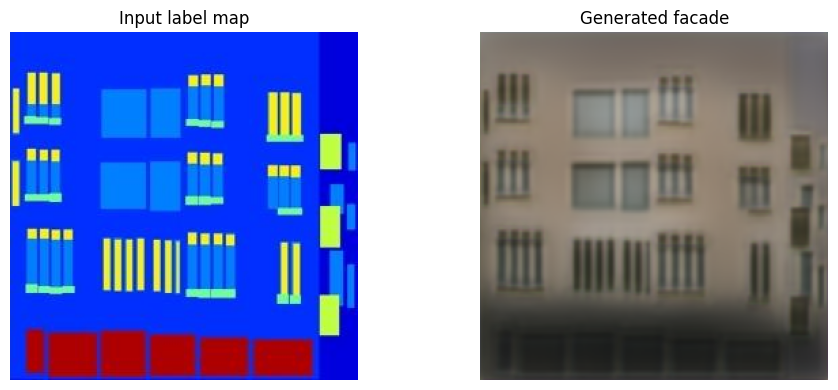

In [12]:
input_img = Image.open(SAMPLE_PATH).convert("RGB")
generated_img = Image.open(OUTPUT_PATH).convert("RGB")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(input_img)
plt.title("Input label map")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(generated_img)
plt.title("Generated facade")
plt.axis("off")

plt.tight_layout()
plt.show()

## 13. Final check

This cell confirms that the output image was created and reports the model size.

In [13]:
print("Generated output exists:", OUTPUT_PATH.exists())
print("Generated output path:", OUTPUT_PATH)

model_size_mb = MODEL_PATH.stat().st_size / (1024 * 1024)
print(f"Model size: {model_size_mb:.2f} MB")


Generated output exists: True
Generated output path: /Users/ana/Documents/DEMO/demo/outputs/generated_sample.png
Model size: 149.57 MB
